0. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_theme(color_codes=True)

In [2]:
import os
import kagglehub

path = kagglehub.dataset_download(
    "aldinwhyudii/student-depression-and-lifestyle-100k-data", output_dir = "./data"
    )

df = pd.read_csv(os.path.join(path, "student_lifestyle_100k.csv"))
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


1. Разведочный анализ данных и визуализация

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [4]:
#удаляем столбец id, так как он не несет полезной информации для анализа
#удаляем строки с некорректной суммой часов в сутках (больше 24 часов)
#удаляем дубликаты строк

invalid_time_mask = (df["Sleep_Duration"] + df["Study_Hours"] + df["Social_Media_Hours"] > 24)
df.drop(index=df[invalid_time_mask].index, inplace=True)
df.drop(columns=["Student_ID"], inplace=True)
df.drop_duplicates(inplace=True)

print(df.shape)
df.head()

(99921, 10)


,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [5]:
df.describe()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000
mean,21.008887,2.898246,6.994291,4.505956,3.501174,74.352458,4.131504
std,2.000381,0.532189,1.496934,1.972359,1.485036,43.363229,1.424150
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object","bool"]).columns.tolist()

for col in categorical_cols:
    print(df[col].value_counts())

Gender
Male      50078
Female    49843
Name: count, dtype: int64
Department
Science        20056
Engineering    20040
Arts           19981
Medical        19948
Business       19896
Name: count, dtype: int64
Depression
False    89864
True     10057
Name: count, dtype: int64


/tmp/ipykernel_34876/1387818995.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object","bool"]).columns.tolist()


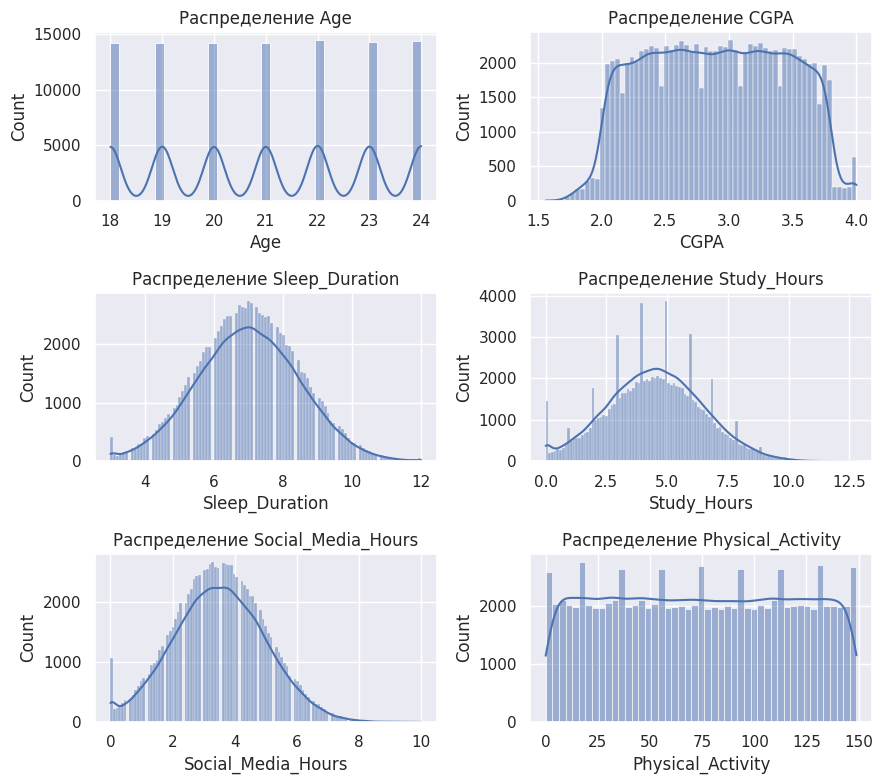

In [7]:
cols_for_histogram = ["Age",
    "CGPA",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Physical_Activity"
]

fig, axes = plt.subplots(3,2, figsize=(9,8))
axes = axes.flatten()

for i, col in enumerate(cols_for_histogram):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f"Распределение {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

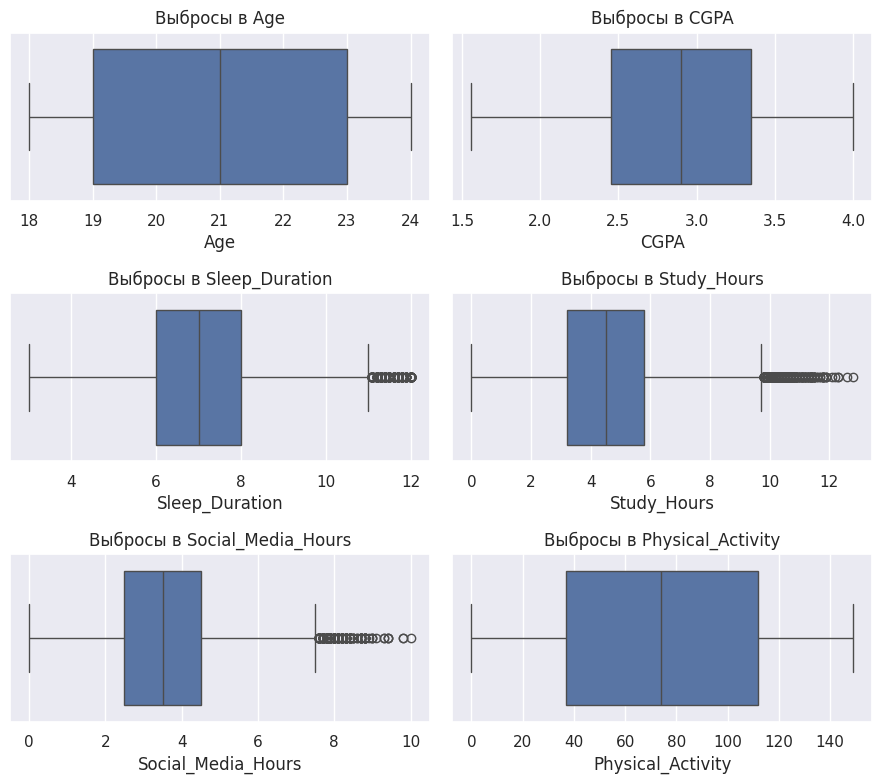

In [8]:
cols_for_boxplot = [
    "Age",
    "CGPA",
    "Sleep_Duration",
    "Study_Hours",
    "Social_Media_Hours",
    "Physical_Activity"
]

fig, axes = plt.subplots(3, 2, figsize=(9, 8))
axes = axes.flatten()

for i, col in enumerate(cols_for_boxplot):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Выбросы в {col}")

plt.tight_layout()
plt.show()

2. Предобработка данных

In [9]:
from sklearn.preprocessing import OneHotEncoder

missing_count = df.isnull().sum()
print("Количество пропусков:")
print(missing_count)
print("==========================")
print("Age < 0:", (df["Age"] < 0).sum())
print("Age > 100:", (df["Age"] > 100).sum())
print("CGPA < 0:", (df["CGPA"] < 0).sum())
print("CGPA > 4:", (df["CGPA"] > 4).sum())
print("Sleep_Duration < 0:", (df["Sleep_Duration"] < 0).sum())
print("Study_Hours < 0:", (df["Study_Hours"] < 0).sum())
print("Social_Media_Hours < 0:", (df["Social_Media_Hours"] < 0).sum())
print("Physical_Activity < 0:", (df["Physical_Activity"] < 0).sum())
print("Stress_Level < 0:", (df["Stress_Level"] < 0).sum())
print("==========================")

# Бинарные признаки
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df["Depression"] = df["Depression"].astype(int)

# One-hot encoding для Department
ohe = OneHotEncoder(sparse_output=False, drop="first")

department_encoded = ohe.fit_transform(df[["Department"]])

department_df = pd.DataFrame(
    department_encoded,
    columns=ohe.get_feature_names_out(["Department"]),
    index=df.index
)

df = pd.concat([df.drop(columns=["Department"]), department_df], axis=1)
display(df.head())
df.info()

Количество пропусков:
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64
Age < 0: 0
Age > 100: 0
CGPA < 0: 0
CGPA > 4: 0
Sleep_Duration < 0: 0
Study_Hours < 0: 0
Social_Media_Hours < 0: 0
Physical_Activity < 0: 0
Stress_Level < 0: 0


,Age,Gender,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,22,0,3.50,7.3,3.3,3.4,114,5,0,0.0,0.0,0.0,1.0
1,20,1,2.72,5.5,7.2,6.0,142,2,0,0.0,1.0,0.0,0.0
2,20,1,3.01,5.4,2.3,1.8,137,3,0,0.0,0.0,1.0,0.0
3,21,1,3.63,8.1,2.0,4.6,130,3,0,0.0,1.0,0.0,0.0
4,19,1,3.14,6.8,2.6,4.3,4,6,0,0.0,0.0,0.0,0.0


<class 'pandas.DataFrame'>
Index: 99921 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     99921 non-null  int64  
 1   Gender                  99921 non-null  int64  
 2   CGPA                    99921 non-null  float64
 3   Sleep_Duration          99921 non-null  float64
 4   Study_Hours             99921 non-null  float64
 5   Social_Media_Hours      99921 non-null  float64
 6   Physical_Activity       99921 non-null  int64  
 7   Stress_Level            99921 non-null  int64  
 8   Depression              99921 non-null  int64  
 9   Department_Business     99921 non-null  float64
 10  Department_Engineering  99921 non-null  float64
 11  Department_Medical      99921 non-null  float64
 12  Department_Science      99921 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 10.7 MB


3. Feature engineering

In [10]:
df["Free_Time"] = 24 - df["Sleep_Duration"] - df["Study_Hours"] - df["Social_Media_Hours"]
df["Activity_Hours"] = df["Physical_Activity"] / 60

display(df[["Free_Time", "Activity_Hours"]].describe())

,Free_Time,Activity_Hours
count,9.992100e+04,99921.000000
mean,8.998579e+00,1.239208
std,2.885258e+00,0.722720
min,-8.881784e-16,0.000000
25%,7.000000e+00,0.616667
50%,9.000000e+00,1.233333
75%,1.100000e+01,1.866667
max,2.060000e+01,2.483333


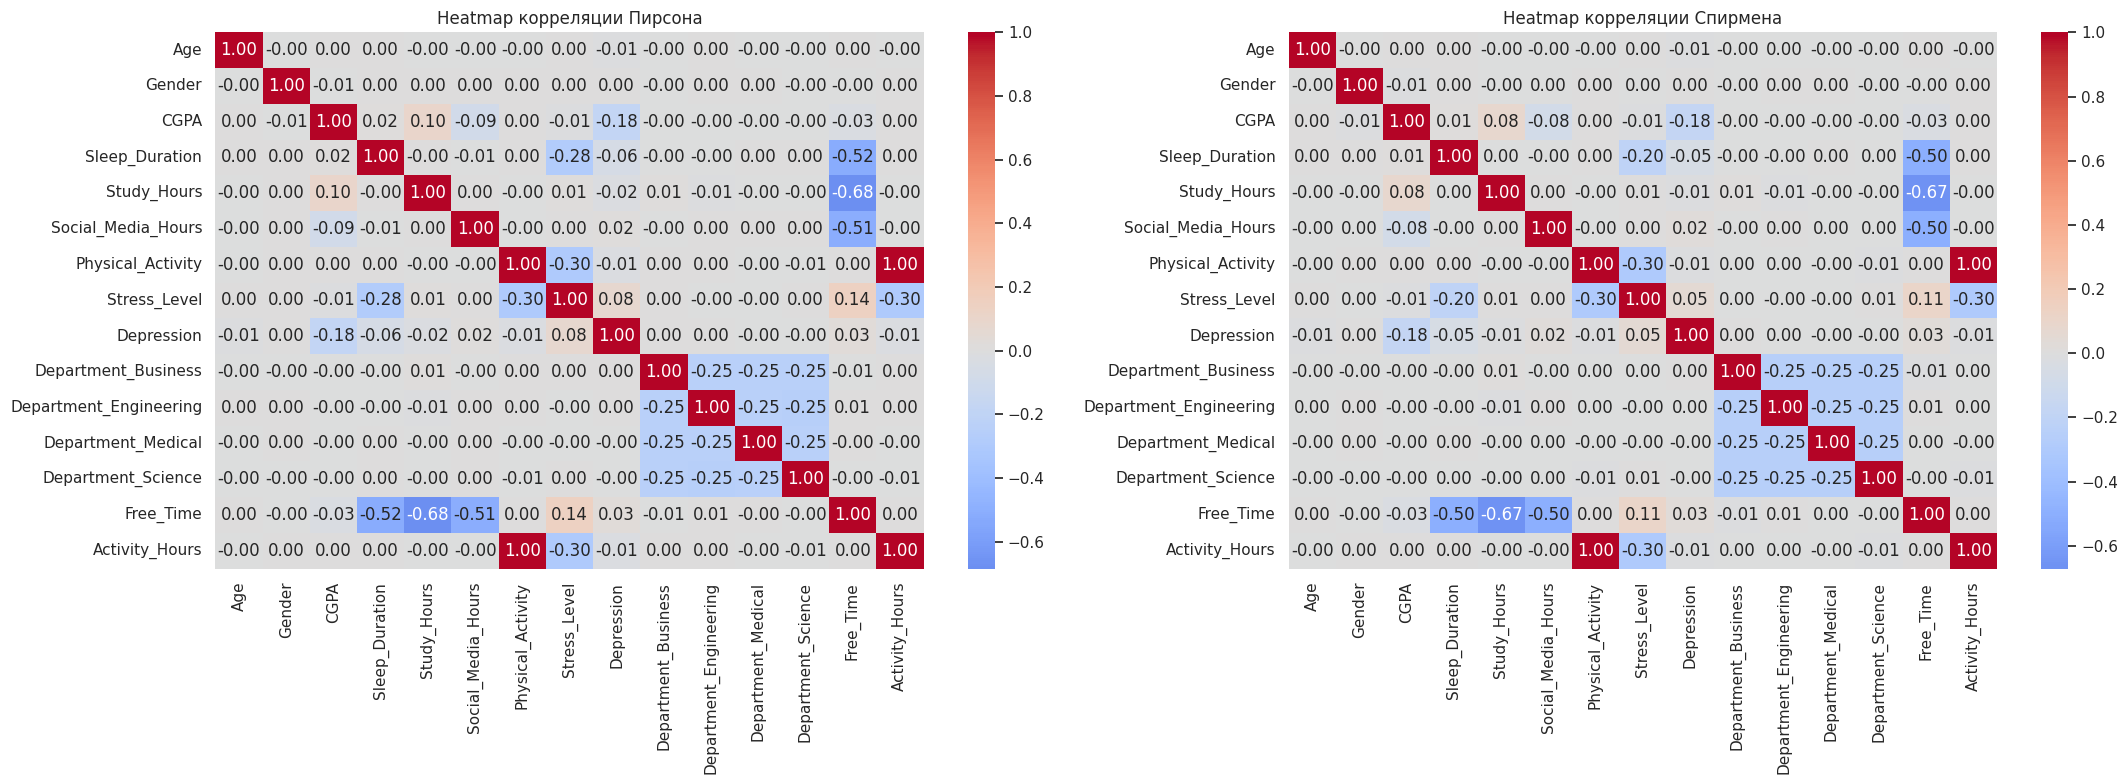

In [11]:
pearson_corr = df.corr(method ="pearson")
spearman_corr = df.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    cbar=True,
    ax=axes[0]
)
axes[0].set_title("Heatmap корреляции Пирсона")

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    cbar=True,
    ax=axes[1]
)
axes[1].set_title("Heatmap корреляции Спирмена")

plt.tight_layout()
plt.show()

Для задачи прогнозирования CGPA были выбраны Sleep_Duration и Study_Hours, поскольку они напрямую соответствуют постановке задачи. 
Дополнительно включены Social_Media_Hours, Stress_Level, Depression и созданный признак Free_Time как факторы, которые могут быть связаны с успеваемостью. 
Несмотря на то, что корреляции с CGPA в основном слабые, Study_Hours показывает наибольшую положительную связь, а Social_Media_Hours и Depression — слабую отрицательную.

Для предсказания Depression были выбраны Sleep_Duration, Study_Hours, Social_Media_Hours, Activity_Hours, Free_Time, Stress_Level и CGPA. 
Эти признаки отражают режим дня, физическую активность, учебную нагрузку и уровень стресса студента. 
Признаки Age, Gender и Department не использовались из-за близкой к нулю корреляции с целевыми переменными.

In [12]:
reg_features = ["Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Stress_Level", "Depression", "Free_Time"]
print("Признаки для CGPA:", reg_features)

clf_features = ["Sleep_Duration", "Study_Hours", "Social_Media_Hours", "Activity_Hours", "Free_Time", "Stress_Level", "CGPA"]
print("Признаки для Depression:", clf_features)

Признаки для CGPA: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Depression', 'Free_Time']
Признаки для Depression: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Activity_Hours', 'Free_Time', 'Stress_Level', 'CGPA']


4. Разделение данных

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Выбор признаков и целевой переменной

X_reg = df[reg_features]
y_reg = df["CGPA"]

# 2. Сначала отделяем test

X_reg_temp, X_reg_test, y_reg_temp, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.15,
    random_state=42,
    shuffle=True
)


# 3. Из оставшихся данных выделяем validation

X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_temp, y_reg_temp,
    test_size=0.1765,   
    random_state=42,
    shuffle=True
)


print("Регрессия:")
print("Train:", X_reg_train.shape, y_reg_train.shape)
print("Val:  ", X_reg_val.shape, y_reg_val.shape)
print("Test: ", X_reg_test.shape, y_reg_test.shape)

Регрессия:
Train: (69941, 6) (69941,)
Val:   (14991, 6) (14991,)
Test:  (14989, 6) (14989,)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Выбор признаков и целевой переменной

X_clf = df[clf_features]
y_clf = df["Depression"]

# 2. Сначала отделяем test

X_clf_temp, X_clf_test, y_clf_temp, y_clf_test = train_test_split(
    X_clf, y_clf,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=y_clf
)

# 3. Из оставшихся данных выделяем validation

X_clf_train, X_clf_val, y_clf_train, y_clf_val = train_test_split(
    X_clf_temp, y_clf_temp,
    test_size=0.1765,
    random_state=42,
    shuffle=True,
    stratify=y_clf_temp
)


print("Классификация:")
print("Train:", X_clf_train.shape, y_clf_train.shape)
print("Val:  ", X_clf_val.shape, y_clf_val.shape)
print("Test: ", X_clf_test.shape, y_clf_test.shape)

Классификация:
Train: (69941, 7) (69941,)
Val:   (14991, 7) (14991,)
Test:  (14989, 7) (14989,)


5. Линейная регрессия

5.1 коррекция выбросов

Для линейной регрессии была выполнена коррекция выбросов методом межквартильного размаха (IQR). Границы допустимых значений рассчитывались только по обучающей выборке, после чего те же границы применялись к валидационной и тестовой выборкам. Такой подход позволяет избежать утечки данных и уменьшить влияние аномальных наблюдений на линейную модель.

In [15]:
train_mask = pd.Series(True, index= X_reg_train.index)
val_mask = pd.Series(True, index = X_reg_val.index)
test_mask = pd.Series(True, index = X_reg_test.index)

for col in reg_features:
    if X_reg_train[col].nunique() <=2:
        continue
    q1 = X_reg_train[col].quantile(0.25)
    q3 = X_reg_train[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    train_mask &= X_reg_train[col].between(lower, upper)
    val_mask &= X_reg_val[col].between(lower, upper)
    test_mask &= X_reg_test[col].between(lower, upper)

X_reg_train = X_reg_train[train_mask]
y_reg_train = y_reg_train[train_mask]

X_reg_val = X_reg_val[val_mask]
y_reg_val = y_reg_val[val_mask]

X_reg_test = X_reg_test[test_mask]
y_reg_test = y_reg_test[test_mask]

print("Размеры после коррекции выбросов:")
print("Обучающая выборка:", X_reg_train.shape, y_reg_train.shape)
print("Валидационная выборка:", X_reg_val.shape, y_reg_val.shape)
print("Тестовая выборка:", X_reg_test.shape, y_reg_test.shape)

Размеры после коррекции выбросов:
Обучающая выборка: (68614, 6) (68614,)
Валидационная выборка: (14703, 6) (14703,)
Тестовая выборка: (14688, 6) (14688,)


### 5.2 Масштабирование признаков

После коррекции выбросов числовые признаки были стандартизованы с помощью `StandardScaler`.  
Масштабирование выполнялось только для непрерывных числовых признаков, поскольку бинарные признаки уже находятся в интерпретируемом формате 0/1.

Параметры масштабирования — среднее и стандартное отклонение — рассчитывались только по обучающей выборке.  
Затем те же параметры применялись к валидационной и тестовой выборкам, что предотвращает утечку данных.

In [16]:
from sklearn.preprocessing import StandardScaler

reg_scale_cols = [col for col in X_reg_train.columns if X_reg_train[col].nunique() > 2]

print("Признаки для масштабирования:", reg_scale_cols)

X_reg_train_scaled = X_reg_train.copy()
X_reg_val_scaled = X_reg_val.copy()
X_reg_test_scaled = X_reg_test.copy()

scaler_reg = StandardScaler()

X_reg_train_scaled[reg_scale_cols] = scaler_reg.fit_transform(X_reg_train[reg_scale_cols])
X_reg_val_scaled[reg_scale_cols] = scaler_reg.transform(X_reg_val[reg_scale_cols])
X_reg_test_scaled[reg_scale_cols] = scaler_reg.transform(X_reg_test[reg_scale_cols])

print("Размеры после масштабирования:")

display(X_reg_train_scaled.head())


Признаки для масштабирования: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Free_Time']
Размеры после масштабирования:


,Sleep_Duration,Study_Hours,Social_Media_Hours,Stress_Level,Depression,Free_Time
8160,0.140606,-0.149753,-0.886430,-1.519267,0,0.491886
10487,1.304560,1.300515,1.305827,-0.795930,0,-2.257336
2106,-1.228752,0.316405,-1.297478,-0.795930,0,1.098857
84244,0.277542,-1.185659,1.990907,-0.072593,0,-0.365014
95588,0.756817,-0.253344,-0.269857,-0.072593,0,-0.079381


### 5.3 Обучение линейной регрессии

После коррекции выбросов и масштабирования признаков была обучена модель `LinearRegression` для прогнозирования значения `CGPA`.  
Модель обучалась только на обучающей выборке. Затем были получены предсказания для обучающей, валидационной и тестовой выборок, чтобы далее сравнить качество модели на разных частях данных.

In [17]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_reg_train_scaled, y_reg_train)

y_reg_train_pred = lin_reg.predict(X_reg_train_scaled)
y_reg_val_pred = lin_reg.predict(X_reg_val_scaled)
y_reg_test_pred = lin_reg.predict(X_reg_test_scaled)

### 5.4 Оценка качества модели

Для оценки качества линейной регрессии были рассчитаны метрики MAE, MSE, RMSE и R² на обучающей, валидационной и тестовой выборках.  
MAE и RMSE позволяют оценить среднюю величину ошибки в шкале целевой переменной `CGPA`, а R² показывает, насколько хорошо модель объясняет разброс целевой переменной.  
Сравнение метрик на train, validation и test позволяет оценить устойчивость модели и наличие переобучения.

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse= np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

reg_metrics = pd.DataFrame({
    "Train": regression_metrics(y_reg_train, y_reg_train_pred),
    "Val": regression_metrics(y_reg_val, y_reg_val_pred),
    "Test": regression_metrics(y_reg_test, y_reg_test_pred)
}).T

display(reg_metrics.round(4))

,MAE,MSE,RMSE,R2
Train,0.4456,0.2704,0.5200,0.0484
Val,0.4400,0.2658,0.5156,0.0494
Test,0.4417,0.2670,0.5167,0.0468


Метрики на обучающей, валидационной и тестовой выборках находятся на близком уровне, что говорит об отсутствии выраженного переобучения. Средняя абсолютная ошибка модели составляет около 0.44 CGPA, а RMSE — около 0.52 CGPA.

При этом значение R² находится примерно на уровне 0.05, то есть модель объясняет лишь небольшую часть разброса целевой переменной. Это указывает на слабую линейную зависимость между выбранными признаками и `CGPA`, что согласуется с результатами корреляционного анализа.

## 5.5 Анализ коэффициентов линейной регрессии

In [19]:
coef_df = pd.DataFrame({
    "Feature": X_reg_train_scaled.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

display(coef_df)

,Feature,Coefficient
1,Study_Hours,0.045147
0,Sleep_Duration,0.000913
3,Stress_Level,0.000483
5,Free_Time,-0.006011
2,Social_Media_Hours,-0.049095
4,Depression,-0.310731


## 5.6 Визуализация результатов линейной регрессии

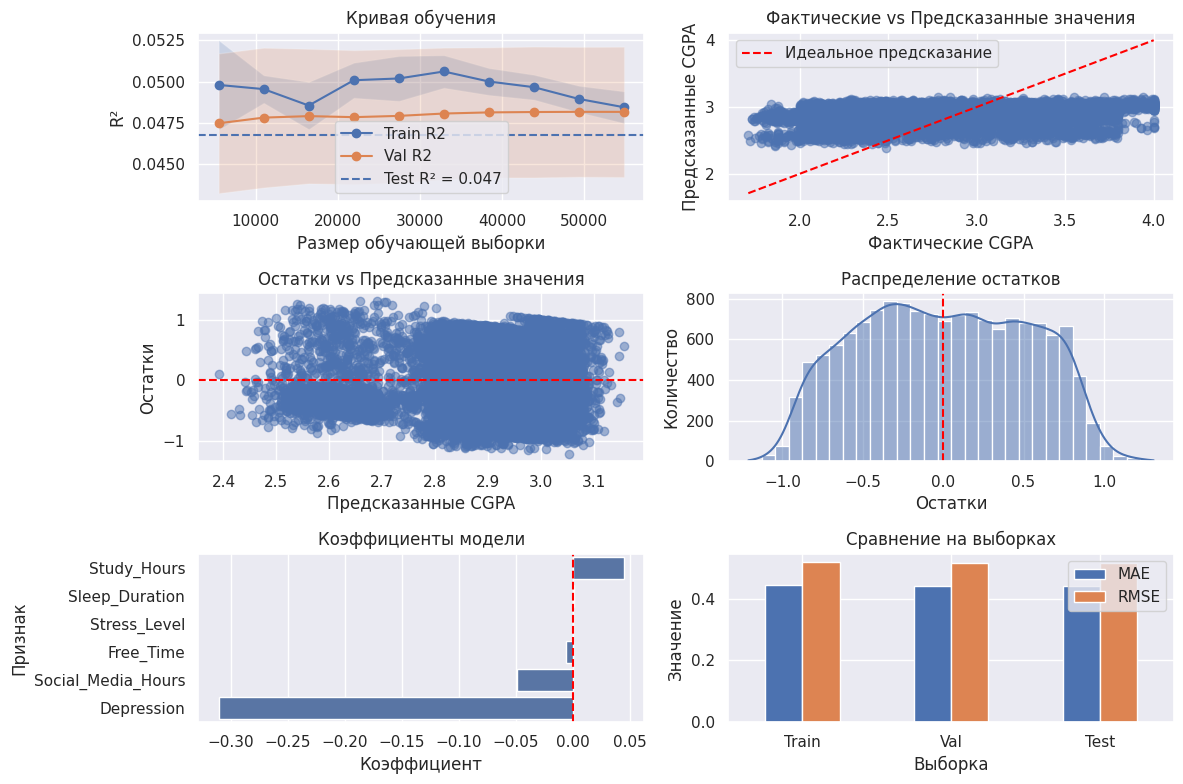

In [20]:
from sklearn.model_selection import learning_curve

residuals = y_reg_test - y_reg_test_pred

train_sizes, train_scores, val_scores = learning_curve(
    estimator=LinearRegression(),
    X=X_reg_train_scaled,
    y=y_reg_train,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv = 5,
    scoring = "r2",
    n_jobs=-1
)

train_scores_mean = train_scores.mean(axis = 1)
train_scores_std = train_scores.std(axis = 1)

val_scores_mean = val_scores.mean(axis = 1)
val_scores_std = val_scores.std(axis = 1)

fig, axes = plt.subplots(3,2, figsize = (12, 8))

# 1. Кривая обучения

axes[0,0].plot(
    train_sizes,
    train_scores_mean,
    marker="o",
    label="Train R2"
)

axes[0,0].fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

axes[0,0].plot(
    train_sizes,
    val_scores_mean,
    marker="o",
    label="Val R2"
)

axes[0,0].fill_between(
    train_sizes,
    val_scores_mean - val_scores_std,
    val_scores_mean + val_scores_std,
    alpha=0.2
)

axes[0,0].axhline(
    reg_metrics.loc["Test", "R2"],
    linestyle="--",
    label = f'Test R² = {reg_metrics.loc["Test", "R2"]:.3f}'
)

axes[0,0].set_title("Кривая обучения")
axes[0,0].set_xlabel("Размер обучающей выборки")
axes[0,0].set_ylabel("R²")
axes[0,0].legend()
axes[0,0].grid(True)

# 2. Фактические и предсказанные значения
axes[0,1].scatter(
    y_reg_test,
    y_reg_test_pred,
    alpha=0.5
)

min_val = min(y_reg_test.min(), y_reg_test_pred.min())
max_val = max(y_reg_test.max(), y_reg_test_pred.max())

axes[0,1].plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Идеальное предсказание"
)

axes[0,1].set_title("Фактические vs Предсказанные значения")
axes[0,1].set_xlabel("Фактические CGPA")
axes[0,1].set_ylabel("Предсказанные CGPA")
axes[0,1].legend()
axes[0,1].grid(True)

# 3. Остатки
axes[1,0].scatter(
    y_reg_test_pred,
    residuals,
    alpha=0.5
)

axes[1,0].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[1,0].set_title("Остатки vs Предсказанные значения")
axes[1,0].set_xlabel("Предсказанные CGPA")
axes[1,0].set_ylabel("Остатки")
axes[1,0].grid(True)

#4 Распределение остатков

sns.histplot(
    residuals,
    kde = True,
    bins = 30,
    ax= axes[1,1]
)

axes[1,1].axvline(
    0,
    color="red",
    linestyle="--"
)

axes[1,1].set_title("Распределение остатков")
axes[1,1].set_xlabel("Остатки")
axes[1,1].set_ylabel("Количество")

# 5. Коэффициенты модели

sns.barplot(
    data = coef_df,
    x="Coefficient",
    y="Feature",
    ax=axes[2,0]
)

axes[2,0].axvline(
    0,
    color="red",
    linestyle="--"
)   

axes[2,0].set_title("Коэффициенты модели")
axes[2,0].set_xlabel("Коэффициент")
axes[2,0].set_ylabel("Признак")

# 6 Сравнение MAE и RMSE

error_metrics = reg_metrics[["MAE", "RMSE"]]

error_metrics.plot(
    kind="bar",
    ax=axes[2,1]
)

axes[2,1].set_title("Сравнение на выборках")
axes[2,1].set_xlabel("Выборка")
axes[2,1].set_ylabel("Значение")
axes[2,1].tick_params(axis = "x", rotation=0)
axes[2,1].grid(True, axis="y")

plt.tight_layout()
plt.show()

6. Логистическая регрессия

Для задачи классификации используется логистическая регрессия через `SGDClassifier` с `loss="log_loss"`. 
Так можно явно менять шаг обучения (`eta0`) и число эпох (`max_iter`). 
Из-за дисбаланса классов добавлен `class_weight="balanced"`.

6.1 Проверка баланса классов

In [21]:
print("Распределение классов Depression:")
print(y_clf.value_counts(normalize=True))

print()
print("Train:")
print(y_clf_train.value_counts(normalize=True))

print()
print("Val:")
print(y_clf_val.value_counts(normalize=True))

print()
print("Test:")
print(y_clf_test.value_counts(normalize=True))

Распределение классов Depression:
Depression
0    0.89935
1    0.10065
Name: proportion, dtype: float64

Train:
Depression
0    0.899358
1    0.100642
Name: proportion, dtype: float64

Val:
Depression
0    0.89934
1    0.10066
Name: proportion, dtype: float64

Test:
Depression
0    0.899326
1    0.100674
Name: proportion, dtype: float64


6.2 Масштабирование признаков

In [22]:
clf_scale_cols = [col for col in X_clf_train.columns if X_clf_train[col].nunique() > 2]

print("Признаки для масштабирования:", clf_scale_cols)

X_clf_train_scaled = X_clf_train.copy()
X_clf_val_scaled = X_clf_val.copy()
X_clf_test_scaled = X_clf_test.copy()

scaler_clf = StandardScaler()

X_clf_train_scaled[clf_scale_cols] = scaler_clf.fit_transform(X_clf_train[clf_scale_cols])
X_clf_val_scaled[clf_scale_cols] = scaler_clf.transform(X_clf_val[clf_scale_cols])
X_clf_test_scaled[clf_scale_cols] = scaler_clf.transform(X_clf_test[clf_scale_cols])

display(X_clf_train_scaled.head())

Признаки для масштабирования: ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Activity_Hours', 'Free_Time', 'Stress_Level', 'CGPA']


,Sleep_Duration,Study_Hours,Social_Media_Hours,Activity_Hours,Free_Time,Stress_Level,CGPA
67274,-0.928378,1.518520,0.671410,-0.194034,-0.901832,-0.092191,0.641810
55934,0.674850,-0.003364,0.065090,-0.838985,-0.381589,0.608213,1.130722
46994,-0.727974,-2.286190,0.334565,0.704289,1.768748,-0.792594,1.393981
82768,0.207242,-1.068683,-0.002279,0.566086,0.624214,-1.492998,1.412786
55671,-0.126764,0.148824,-0.271754,1.464410,0.103971,-0.792594,-0.373621


6.3 Подбор learning rate и числа эпох

In [23]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

learning_rates = [0.001, 0.005, 0.01]
epochs_list = [200, 500, 1000]

clf_results = []

for lr in learning_rates:
    for epochs in epochs_list:
        log_reg = SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=0.0001,
            learning_rate="constant",
            eta0=lr,
            max_iter=epochs,
            tol=None,
            random_state=42,
            class_weight="balanced"
        )
        log_reg.fit(X_clf_train_scaled, y_clf_train)

        y_val_pred = log_reg.predict(X_clf_val_scaled)
        y_val_proba = log_reg.predict_proba(X_clf_val_scaled)[:, 1]

        clf_results.append({
            "learning_rate": lr,
            "epochs": epochs,
            "Accuracy": accuracy_score(y_clf_val, y_val_pred),
            "Precision": precision_score(y_clf_val, y_val_pred, zero_division=0),
            "Recall": recall_score(y_clf_val, y_val_pred, zero_division=0),
            "F1": f1_score(y_clf_val, y_val_pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y_clf_val, y_val_proba)
        })

clf_results_df = pd.DataFrame(clf_results).sort_values(by="F1", ascending=False)
display(clf_results_df.round(4))

,learning_rate,epochs,Accuracy,Precision,Recall,F1,ROC_AUC
4,0.005,500,0.6894,0.1821,0.5971,0.2790,0.6882
0,0.001,200,0.6404,0.1741,0.6872,0.2778,0.6975
2,0.001,1000,0.6332,0.1720,0.6932,0.2756,0.6973
7,0.010,500,0.7328,0.1887,0.5017,0.2743,0.6831
1,0.001,500,0.6286,0.1706,0.6965,0.2741,0.6939
3,0.005,200,0.6391,0.1690,0.6600,0.2691,0.6855
5,0.005,1000,0.6108,0.1653,0.7078,0.2680,0.6964
8,0.010,1000,0.6036,0.1629,0.7097,0.2649,0.6926
6,0.010,200,0.6286,0.1645,0.6594,0.2633,0.6817


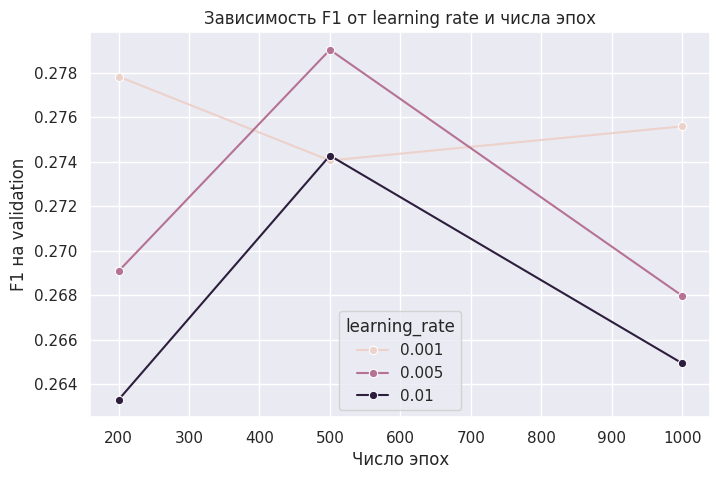

In [24]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=clf_results_df,
    x="epochs",
    y="F1",
    hue="learning_rate",
    marker="o"
)

plt.title("Зависимость F1 от learning rate и числа эпох")
plt.xlabel("Число эпох")
plt.ylabel("F1 на validation")
plt.grid(True)
plt.show()

6.4 Обучение лучшей модели

In [25]:
best_params = clf_results_df.iloc[0]

best_log_reg = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    learning_rate="constant",
    eta0=best_params["learning_rate"],
    max_iter=int(best_params["epochs"]),
    tol=None,
    random_state=42,
    class_weight="balanced"
)

best_log_reg.fit(X_clf_train_scaled, y_clf_train)

print("Лучшие параметры:")
print("learning rate:", best_params["learning_rate"])
print("epochs:", int(best_params["epochs"]))

Лучшие параметры:
learning rate: 0.005
epochs: 500


6.5 Оценка качества классификации

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def classification_metrics(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, y_proba)
    }

clf_metrics = pd.DataFrame({
    "Train": classification_metrics(best_log_reg, X_clf_train_scaled, y_clf_train),
    "Val": classification_metrics(best_log_reg, X_clf_val_scaled, y_clf_val),
    "Test": classification_metrics(best_log_reg, X_clf_test_scaled, y_clf_test)
}).T

display(clf_metrics.round(4))

print(classification_report(
    y_clf_test,
    best_log_reg.predict(X_clf_test_scaled),
    target_names=["No Depression", "Depression"],
    zero_division=0
))

,Accuracy,Precision,Recall,F1,ROC_AUC
Train,0.6814,0.1753,0.5845,0.2697,0.6763
Val,0.6894,0.1821,0.5971,0.2790,0.6882
Test,0.6832,0.1794,0.6004,0.2762,0.6829


               precision    recall  f1-score   support

No Depression       0.94      0.69      0.80     13480
   Depression       0.18      0.60      0.28      1509

     accuracy                           0.68     14989
    macro avg       0.56      0.65      0.54     14989
 weighted avg       0.86      0.68      0.74     14989



Метрики на train, validation и test находятся на близком уровне, поэтому выраженного переобучения у логистической регрессии не наблюдается. Так как класс Depression встречается заметно реже, основной акцент сделан не только на Accuracy, но и на Recall, F1 и ROC-AUC.

6.6 Визуализация результатов логистической регрессии

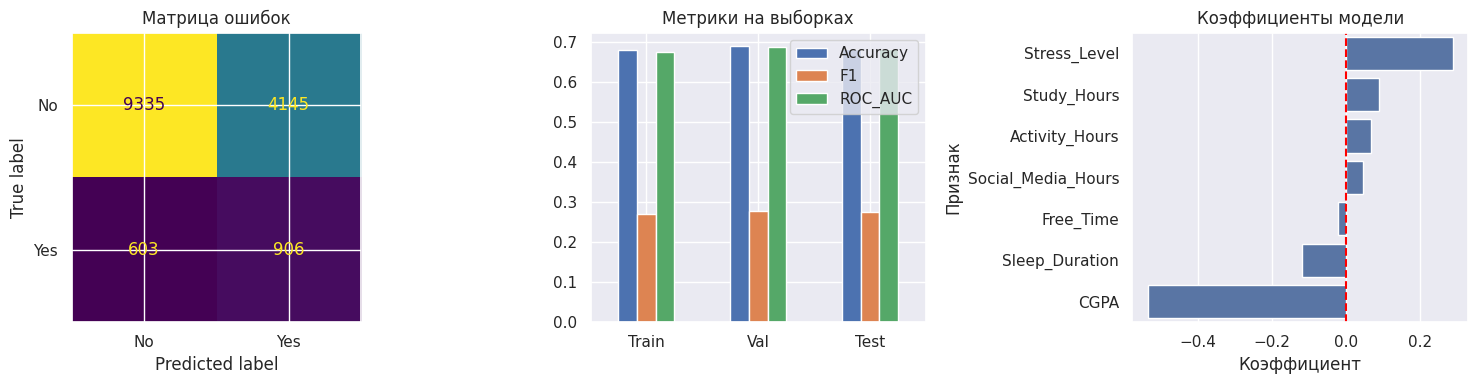

In [27]:
y_clf_test_pred = best_log_reg.predict(X_clf_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_clf_test, y_clf_test_pred),
    display_labels=["No", "Yes"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Матрица ошибок")

clf_metrics[["Accuracy", "F1", "ROC_AUC"]].plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Метрики на выборках")
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(True, axis="y")

clf_coef_df = pd.DataFrame({
    "Feature": X_clf_train_scaled.columns,
    "Coefficient": best_log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

sns.barplot(
    data=clf_coef_df,
    x="Coefficient",
    y="Feature",
    ax=axes[2]
)
axes[2].axvline(0, color="red", linestyle="--")
axes[2].set_title("Коэффициенты модели")
axes[2].set_xlabel("Коэффициент")
axes[2].set_ylabel("Признак")

plt.tight_layout()
plt.show()

7. Итоговые выводы

В работе был выполнен базовый ML-пайплайн: первичный анализ данных, удаление некорректных строк и дублей, кодирование категориальных признаков, создание простых признаков, разбиение на train/validation/test и масштабирование без утечки данных.

Линейная регрессия дает небольшую ошибку в шкале CGPA, но низкий R². Это значит, что выбранные признаки слабо объясняют разброс успеваемости, хотя явного переобучения по метрикам train/validation/test нет.

Логистическая регрессия показывает близкие метрики на обучающей, валидационной и тестовой выборках. Из-за дисбаланса классов точность сама по себе не является достаточной, поэтому дополнительно использовались Precision, Recall, F1 и ROC-AUC.